# QProfiler on the CD4-vs-CD8 T-cell task (with PQK)

Benchmarks classical models and the **projected quantum kernel (PQK)** on the one
*non-trivial* single-cell binary task: **CD4 vs CD8 T cells**.

The other two tasks built earlier (`t_vs_mono`, `lymphoid_vs_myeloid`) are near-perfectly
separable — every model saturates at ~1.0, so they can't discriminate methods, which is
why we focus on **CD4 vs CD8** here.

**How to use:** set models / embeddings / PQK options in the **Configuration** cell and run
top-to-bottom. Classical models finish in seconds; PQK runs on the local statevector
simulator with a shallow, tuned feature map that keeps it fast (see §5).

## 1. Setup and imports

In [15]:
import os
import sys
import shutil
import glob
import yaml
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

import qbiocode as qbc
from qbiocode.apps.qprofiler import qprofiler as profiler
from qbiocode import compute_results_correlation, plot_results_correlation

sns.set_style("whitegrid")

# ---- Portable paths (relative to this notebook; run it from its own directory) ----
NB_DIR = os.getcwd()                                    # this notebook's own directory
DATA_DIR = os.path.join(NB_DIR, "data", "sc_binary")    # per-task CSVs (shipped + rebuildable)
H5AD_DIR = os.path.join(NB_DIR, "data")                 # source h5ads for optional rebuild
CONFIG_TEMPLATE = os.path.join(NB_DIR, "configs", "config.yaml")
OUT_DIR = NB_DIR                                        # ModelResults.csv etc. land here

os.makedirs(DATA_DIR, exist_ok=True)
# QProfiler writes outputs to the current working directory -> pin it to OUT_DIR.
os.chdir(OUT_DIR)
print("qbiocode", qbc.__version__)
print("cwd (outputs):", os.getcwd())

qbiocode 0.1.0
cwd (outputs): /Users/aritrabose/Documents/ISMB26/final/QBioCode/docs/source/tutorials/QProfiler


## 2. Configuration — choose task, models, embeddings

Everything you'd normally tweak lives here.

- `TASK`: one of the three tasks, or `"all"` to benchmark all three (needed for the
  cross-task complexity correlation).
- `LEAKAGE_SAFE`: drop the lineage-defining marker genes (e.g. `CD3D`, `LYZ`, `MS4A1`)
  that trivially reveal the label. Recommended — otherwise classification is trivial.
- `N_FEATURES`: number of top-variance HVGs exported per task. Kept small so complexity
  metrics and QML stay light on a laptop.
- `MODELS`: classical `svc dt lr nb rf mlp` (fast) and/or quantum `qsvc pqk vqc qnn`
  (slow on the local simulator).

In [16]:
# ============================ EXPERIMENT CONFIG ============================
# Focus on CD4 vs CD8 -- the only discriminative task (the other two saturate at ~1.0).
TASK = "cd4_vs_cd8"
LEAKAGE_SAFE = True   # drop label-defining marker genes/proteins
N_FEATURES = 50       # top-variance HVGs to export per task (keeps compute light)

MODELS = ["lr", "svc", "rf", "mlp", "pqk"]   # classical baselines + projected quantum kernel
EMBEDDINGS = ["pca"]  # e.g. ["none"], ["pca","isomap"]
N_COMPONENTS = 8      # dims after embedding (= qubit count for PQK)
ITER = 5              # train/test splits per model-embedding
TEST_SIZE = 0.3

# PQK feature-map tuning. The shipped template uses a DEEP ZZ map (pairwise, reps=4) that
# suffers quantum-kernel *concentration*: the <X>,<Y>,<Z> projections collapse toward 0, so
# the kernel carries little signal (and it is slow). A SHALLOW, linearly-entangled ZZ map
# (reps=1) fixes both -- on cd4_vs_cd8 it lifts PQK accuracy ~0.81 -> ~0.88 and is ~3x faster.
PQK_ARGS = {"encoding": "ZZ", "entanglement": "linear", "primitive": "estimator", "reps": 1}
# ===========================================================================

ALL_TASKS = ["t_vs_mono", "lymphoid_vs_myeloid", "cd4_vs_cd8"]
assert TASK in ALL_TASKS, f"unknown TASK {TASK!r}"
print("Task:", TASK, "| Models:", MODELS)
print("Embeddings:", EMBEDDINGS, "| n_components:", N_COMPONENTS, "| iters:", ITER)
print("PQK_ARGS:", PQK_ARGS)

Task: cd4_vs_cd8 | Models: ['lr', 'svc', 'rf', 'mlp', 'pqk']
Embeddings: ['pca'] | n_components: 8 | iters: 5
PQK_ARGS: {'encoding': 'ZZ', 'entanglement': 'linear', 'primitive': 'estimator', 'reps': 1}


## 3. Build per-task CSV datasets

QProfiler reads plain CSVs (features in columns, **label in the last column**). We export
one CSV per task from the small balanced h5ads (500 cells, 250/class), selecting the top
`N_FEATURES` high-variance HVGs — optionally excluding the label-defining markers to avoid
leakage. Files are named `pbmc-<task>.csv` so they share the `pbmc` datatype prefix, which
lets QProfiler correlate complexity to performance **across** the three tasks.

In [17]:
def export_task_csv(task, n_features, leakage_safe, data_dir, h5ad_dir):
    """Write pbmc-<task>.csv (top-variance HVGs + label) and return (path, info)."""
    adata = ad.read_h5ad(os.path.join(h5ad_dir, f"pbmc5k_small_{task}.h5ad"))

    # gene mask: HVGs, optionally excluding label-defining markers
    keep = adata.var["highly_variable"].to_numpy().copy()
    if leakage_safe and "is_label_leakage" in adata.var:
        keep &= ~adata.var["is_label_leakage"].to_numpy()

    X = adata[:, keep].X
    X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
    genes = adata.var_names[keep].to_numpy()

    # rank by variance across cells, take top-N
    order = np.argsort(X.var(axis=0))[::-1][:n_features]
    X_sel, genes_sel = X[:, order], genes[order]

    df = pd.DataFrame(X_sel, columns=list(genes_sel))
    df["label"] = adata.obs["label"].astype(str).to_numpy()   # label MUST be last column

    path = os.path.join(data_dir, f"pbmc-{task}.csv")
    df.to_csv(path, index=False)
    info = {"task": task, "n_cells": df.shape[0], "n_features": len(genes_sel),
            "classes": df["label"].value_counts().to_dict()}
    return path, info


# Rebuild each task's CSV from its source h5ad when that h5ad is present; otherwise reuse
# the CSV already shipped in DATA_DIR. Only pbmc5k_small_cd4_vs_cd8.h5ad ships with this
# tutorial (the focus task); t_vs_mono / lymphoid_vs_myeloid simply reuse their shipped CSVs.
for t in ALL_TASKS:
    h5ad = os.path.join(H5AD_DIR, f"pbmc5k_small_{t}.h5ad")
    csv = os.path.join(DATA_DIR, f"pbmc-{t}.csv")
    if os.path.exists(h5ad):
        _, info = export_task_csv(t, N_FEATURES, LEAKAGE_SAFE, DATA_DIR, H5AD_DIR)
        print("rebuilt from h5ad:", info)
    else:
        assert os.path.exists(csv), (
            f"no h5ad and no pre-built CSV for {t}; "
            f"add pbmc5k_small_{t}.h5ad to {H5AD_DIR} to build it")
        print(f"using shipped CSV (no h5ad for {t}):", os.path.basename(csv))
print("\nCSVs in", DATA_DIR, "->",
      sorted(os.path.basename(p) for p in glob.glob(DATA_DIR + "/*.csv")))

using shipped CSV (no h5ad for t_vs_mono): pbmc-t_vs_mono.csv
using shipped CSV (no h5ad for lymphoid_vs_myeloid): pbmc-lymphoid_vs_myeloid.csv
rebuilt from h5ad: {'task': 'cd4_vs_cd8', 'n_cells': 500, 'n_features': 50, 'classes': {'CD4_T': 250, 'CD8_T': 250}}

CSVs in /Users/aritrabose/Documents/ISMB26/final/QBioCode/docs/source/tutorials/QProfiler/data/sc_binary -> ['pbmc-cd4_vs_cd8.csv', 'pbmc-lymphoid_vs_myeloid.csv', 'pbmc-t_vs_mono.csv']


## 4. Assemble the QProfiler config

In [18]:
# Start from the shipped template (keeps all model-arg blocks) and override our choices.
config = yaml.safe_load(open(CONFIG_TEMPLATE))

config.update({
    "folder_path": os.path.abspath(DATA_DIR),   # absolute -> independent of cwd
    "file_dataset": "ALL" if TASK == "all" else [f"pbmc-{TASK}.csv"],
    "model": MODELS,
    "embeddings": EMBEDDINGS,
    "n_components": N_COMPONENTS,
    "iter": ITER,
    "test_size": TEST_SIZE,
    "stratify": ["y"],
    "scaling": ["True"],
    "n_jobs": 1,
    "grid_search": False,
    "backend": "simulator",     # only used by QML models
})
config["pqk_args"] = PQK_ARGS   # tuned shallow ZZ map (overrides the template default)

print("file_dataset:", config["file_dataset"])
print("models:", config["model"], "| embeddings:", config["embeddings"])
print("pqk_args:", config["pqk_args"])

file_dataset: ['pbmc-cd4_vs_cd8.csv']
models: ['lr', 'svc', 'rf', 'mlp', 'pqk'] | embeddings: ['pca']
pqk_args: {'encoding': 'ZZ', 'entanglement': 'linear', 'primitive': 'estimator', 'reps': 1}


## 5. Run QProfiler

QProfiler writes/appends to `ModelResults.csv`, `RawDataEvaluation.csv`, and `results.pkl`
in the working directory, so we clear any stale outputs first (otherwise rows accumulate
across runs).

In [19]:
# Clear stale outputs so results reflect only this run.
for f in ["ModelResults.csv", "RawDataEvaluation.csv", "results.pkl"]:
    if os.path.exists(f):
        os.remove(f)
# PQK caches projections keyed by dataset/embedding/iter -- NOT by pqk_args -- so stale
# projections would silently mask a feature-map change. Purge them before each run.
shutil.rmtree("pqk_projections", ignore_errors=True)

profiler.main(config)

model_results = pd.read_csv("ModelResults.csv")
print("ModelResults:", model_results.shape,
      "| datasets:", model_results["Dataset"].unique().tolist())
model_results[["Dataset", "model", "embeddings", "iteration",
               "accuracy", "f1_score", "auc"]].head(12)

Processing file: pbmc-cd4_vs_cd8.csv
at datapoint 0
at datapoint 100
at datapoint 200
at datapoint 300
at datapoint 0
at datapoint 100
at datapoint 0
at datapoint 100
at datapoint 200
at datapoint 300
at datapoint 0
at datapoint 100
at datapoint 0
at datapoint 100
at datapoint 200
at datapoint 300
at datapoint 0
at datapoint 100
at datapoint 0
at datapoint 100
at datapoint 200
at datapoint 300
at datapoint 0
at datapoint 100
at datapoint 0
at datapoint 100
at datapoint 200
at datapoint 300
at datapoint 0
at datapoint 100
ModelResults: (25, 32) | datasets: ['pbmc-cd4_vs_cd8.csv']


,Dataset,model,embeddings,iteration,accuracy,f1_score,auc
0,pbmc-cd4_vs_cd8.csv,lr,pca,1,0.893333,0.892646,0.893333
1,pbmc-cd4_vs_cd8.csv,mlp,pca,1,0.880000,0.879915,0.880000
2,pbmc-cd4_vs_cd8.csv,pqk,pca,1,0.900000,0.899960,0.900000
3,pbmc-cd4_vs_cd8.csv,rf,pca,1,0.893333,0.893029,0.893333
4,pbmc-cd4_vs_cd8.csv,svc,pca,1,0.860000,0.858178,0.860000
5,pbmc-cd4_vs_cd8.csv,lr,pca,2,0.860000,0.859494,0.860000
6,pbmc-cd4_vs_cd8.csv,mlp,pca,2,0.866667,0.866667,0.866667
7,pbmc-cd4_vs_cd8.csv,pqk,pca,2,0.860000,0.859994,0.860000
8,pbmc-cd4_vs_cd8.csv,rf,pca,2,0.833333,0.832731,0.833333
9,pbmc-cd4_vs_cd8.csv,svc,pca,2,0.820000,0.817658,0.820000


## 6. Visualize model performance

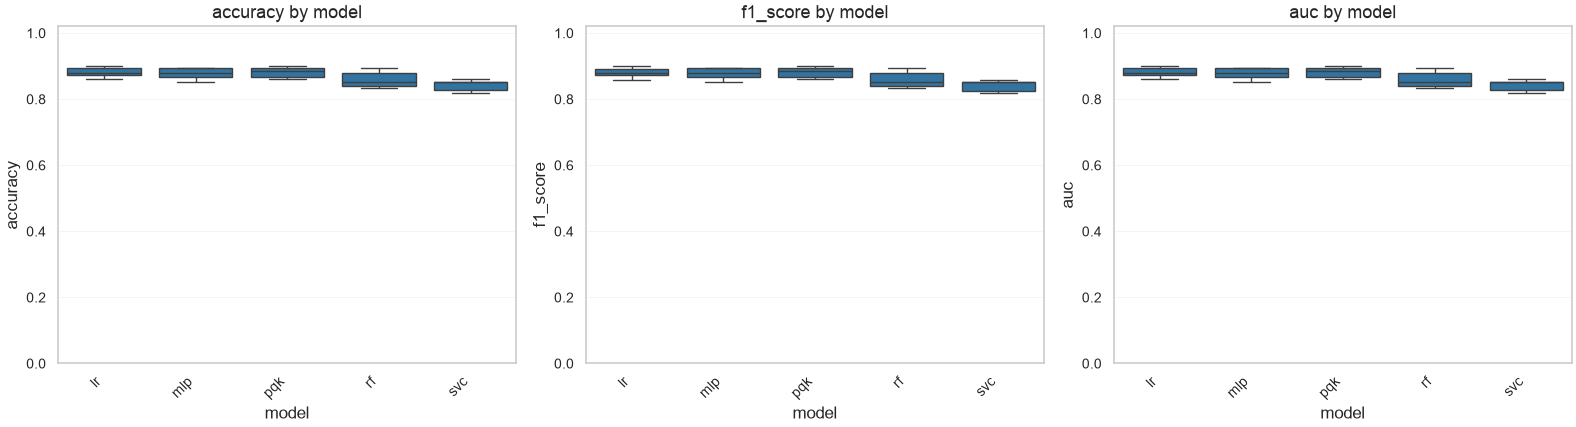

,accuracy,f1_score,auc
model,,,
lr,0.880,0.879,0.880
mlp,0.880,0.880,0.880
pqk,0.887,0.886,0.887
rf,0.853,0.853,0.853
svc,0.853,0.851,0.853


In [20]:
metrics = ["accuracy", "f1_score", "auc"]
multi_ds = model_results["Dataset"].nunique() > 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, metrics):
    if multi_ds:
        sns.boxplot(data=model_results, x="model", y=metric, hue="Dataset", ax=ax)
        ax.legend_.set_title("task") if ax.legend_ else None
    else:
        sns.boxplot(data=model_results, x="model", y=metric, ax=ax)
    ax.set_title(f"{metric} by model")
    ax.set_ylim(0, 1.02)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    if multi_ds and ax is not axes[-1] and ax.legend_:
        ax.legend_.remove()
plt.tight_layout()
plt.show()

# Compact summary table: median metric per model (x task if multiple)
grp = ["Dataset", "model"] if multi_ds else ["model"]
summary = (model_results.groupby(grp)[metrics].median().round(3))
summary

## 7. Classical vs quantum: performance and behaviour

Two complementary views of how the projected quantum kernel (**PQK**) compares with the
**single best classical model** — the classical classifier with the highest median F1, not
an average over the classical methods — in one publication figure.

**Panel A — performance.** PQK against the best classical model across accuracy, F1 and AUC:
the marker is the mean, whiskers the 95% CI over the 5 splits, and faint dots the individual
splits. PQK sits a touch above its strongest classical competitor on all three metrics, but
the intervals overlap — a small, not decisive, edge.

**Panel B — behaviour.** Using QBioCode's `compute_results_correlation`, we take each model's
per-split Spearman ρ between a data-complexity characteristic and F1, then plot
**Δρ = ρ(PQK) − ρ(best classical)** for the characteristics where the two diverge most
(|Δρ| ≥ 0.3). Purple bars = PQK's F1 tracks that characteristic *more positively* than the
best classical model; blue = *less*. This is where quantum and classical "look at" the data
differently — the annotation on each bar gives the underlying `best-classical → PQK` ρ.

> ⚠️ **Power note.** Each split is one point, so both panels rest on **n = 5** — read the
> *direction and size* of the gap, not p-values. A robust classical-vs-quantum claim needs a
> *panel of datasets* spanning complexity.

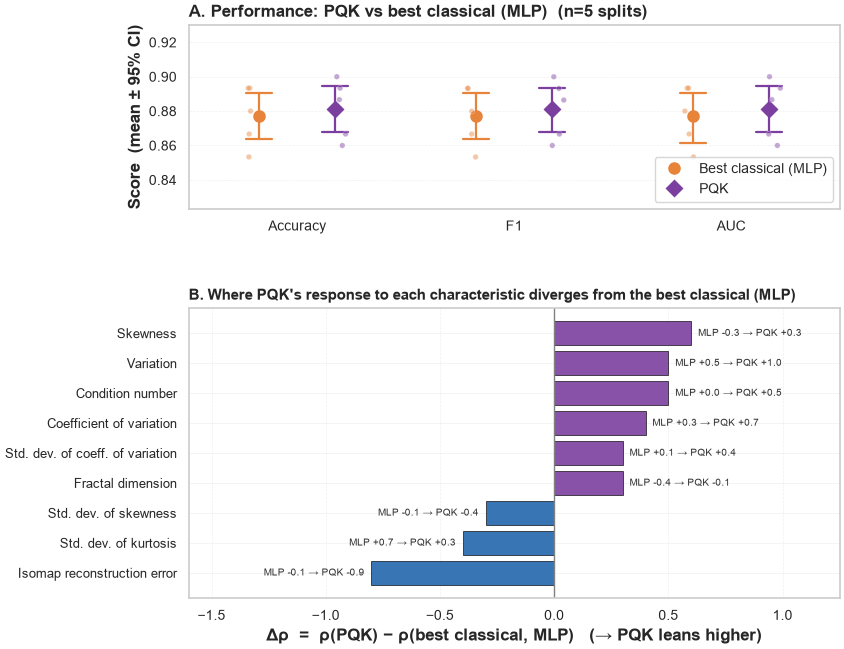

,classical,quantum,delta
Isomap reconstruction error,-0.1,-0.9,-0.8
Std. dev. of kurtosis,0.7,0.3,-0.4
Std. dev. of skewness,-0.1,-0.4,-0.3
Fractal dimension,-0.4,-0.1,0.3
Std. dev. of coeff. of variation,0.1,0.4,0.3
Coefficient of variation,0.3,0.7,0.4
Condition number,0.0,0.5,0.5
Variation,0.5,1.0,0.5
Skewness,-0.3,0.3,0.6


In [22]:
# Classical vs quantum, two ways in one figure. The classical baseline is the SINGLE BEST
# classical model (highest median F1), not an average across classical methods.
#   Panel A — performance: PQK vs best classical across accuracy/F1/AUC (mean ± 95% CI, points).
#   Panel B — behaviour: how PQK's per-split correlation to each data characteristic diverges
#             from the best classical  (Δρ = ρ_PQK − ρ_best-classical).
from matplotlib.gridspec import GridSpec

df7 = model_results[model_results["Dataset"].str.contains("cd4_vs_cd8")].copy()
QUANTUM = {"pqk", "qsvc", "vqc", "qnn"}
present = df7["model"].unique().tolist()
CLASSICAL = [m for m in present if m not in QUANTUM]
QUANT = next(m for m in present if m in QUANTUM)          # PQK here
QLABEL = QUANT.upper()
BEST_CLS = df7[df7["model"].isin(CLASSICAL)].groupby("model")["f1_score"].median().idxmax()
BLABEL = f"Best classical ({BEST_CLS.upper()})"
CCOL, QCOL, NEG = "#E8833A", "#7B3FA0", "#2166AC"
METLAB = {"accuracy": "Accuracy", "f1_score": "F1", "auc": "AUC"}

# ---- Panel A data: best classical model vs the quantum model, per split ----
recs = []
for it, g in df7.groupby("iteration"):
    for met in METLAB:
        recs.append({"metric": METLAB[met], "group": BLABEL,
                     "value": float(g[g["model"] == BEST_CLS][met].iloc[0])})
        recs.append({"metric": METLAB[met], "group": QLABEL,
                     "value": float(g[g["model"] == QUANT][met].iloc[0])})
tidy = pd.DataFrame(recs)

# ---- Panel B data: ρ(characteristic, F1) per model -> best-classical-vs-quantum divergence ----
_, correlations_df = compute_results_correlation(model_results, correlation="spearman", thresh=0.7)
cf = correlations_df[correlations_df["metric"] == "f1_score"].copy()
cf["model"] = cf["model_embed_datatype"].str.split("_").str[0]
mat = cf.pivot_table(index="feature", columns="model", values="correlation")
PRETTY = {
    "Coefficient of Variation %": "Coefficient of variation",
    "std_co_of_v": "Std. dev. of coeff. of variation",
    "std_skew": "Std. dev. of skewness",
    "std_kurt": "Std. dev. of kurtosis",
    "std_var": "Std. dev. of variation",
    "Mean Log Kernel Density": "Mean log kernel density",
    "Isomap Reconstruction Error": "Isomap reconstruction error",
}
mat.index = [PRETTY.get(f, f) for f in mat.index]
div = pd.DataFrame({"classical": mat[BEST_CLS], "quantum": mat[QUANT]}).dropna()
div["delta"] = div["quantum"] - div["classical"]
div_show = div[div["delta"].abs() >= 0.3]                 # keep the biggest divergences
if len(div_show) < 4:
    div_show = div.reindex(div["delta"].abs().sort_values(ascending=False).index[:10])
div_show = div_show.sort_values("delta")

# ---- figure -----------------------------------------------------------------------------
n = len(div_show)
fig = plt.figure(figsize=(8.4, 3.3 + 0.46 * n))
gs = GridSpec(2, 1, height_ratios=[3.0, 0.46 * n + 0.6], hspace=0.42)

axA = fig.add_subplot(gs[0])
sns.pointplot(data=tidy, x="metric", y="value", hue="group", dodge=0.35, linestyle="none",
              palette={BLABEL: CCOL, QLABEL: QCOL}, errorbar=("ci", 95), capsize=0.12,
              markers=["o", "D"], markersize=7, err_kws={"linewidth": 1.6}, ax=axA)
sns.stripplot(data=tidy, x="metric", y="value", hue="group", dodge=0.35,
              palette={BLABEL: CCOL, QLABEL: QCOL}, alpha=0.45, size=4, jitter=0.06,
              edgecolor="white", linewidth=0.4, legend=False, ax=axA)
axA.set_ylim(tidy["value"].min() - 0.03, tidy["value"].max() + 0.03)
axA.set_xlabel(""); axA.set_ylabel("Score  (mean ± 95% CI)", fontweight="bold")
axA.set_title(f"A. Performance: {QLABEL} vs best classical ({BEST_CLS.upper()})  "
              f"(n={df7['iteration'].nunique()} splits)", fontweight="bold", loc="left", fontsize=12)
h, l = axA.get_legend_handles_labels()
axA.legend(h[:2], l[:2], title="", loc="lower right", frameon=True)
axA.grid(axis="y", alpha=0.3, ls="--")

axB = fig.add_subplot(gs[1])
y = np.arange(n)
axB.barh(y, div_show["delta"], color=[QCOL if d >= 0 else NEG for d in div_show["delta"]],
         edgecolor="k", linewidth=0.5, alpha=0.9)
axB.axvline(0, color="grey", lw=1)
for yi, (_, r) in zip(y, div_show.iterrows()):
    axB.text(r["delta"] + (0.03 if r["delta"] >= 0 else -0.03), yi,
             f"{BEST_CLS.upper()} {r['classical']:+.1f} → {QLABEL} {r['quantum']:+.1f}",
             va="center", ha="left" if r["delta"] >= 0 else "right", fontsize=7.5, color="#333333")
axB.set_yticks(y); axB.set_yticklabels(div_show.index, fontsize=9)
axB.set_xlim(-1.6, 1.25)
axB.set_xlabel(f"Δρ  =  ρ({QLABEL}) − ρ(best classical, {BEST_CLS.upper()})   (→ {QLABEL} leans higher)",
               fontweight="bold")
axB.set_title(f"B. Where {QLABEL}'s response to each characteristic diverges from "
              f"the best classical ({BEST_CLS.upper()})", fontweight="bold", loc="left", fontsize=10.5)
axB.grid(axis="x", alpha=0.3, ls="--")

plt.savefig(os.path.join(OUT_DIR, "qprofiler_cd4_vs_cd8_classical_vs_quantum.pdf"),
            dpi=600, bbox_inches="tight")
plt.show()
div_show.round(2)